# 📊 Reporte Semanal de Competencias
---
**Instrucciones:** 
1. Coloca `QM-CAPS.xlsx` y tu archivo actualizado de data en la **misma carpeta** que este notebook
2. En la celda de abajo, cambia el nombre del archivo `DATA_FILE` si es diferente
3. Corre todas las celdas (Run All)
4. El notebook guarda automáticamente un snapshot para comparar la próxima semana

## ⚙️ Configuración

In [5]:
QM_FILE = "QM-W12.xlsx"       
DATA_FILE = "QM-27Marzo.xlsx"  

In [6]:
QM_FILE

'QM-W12.xlsx'

## 📥 Carga de datos

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os, shutil, warnings
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

SNAPSHOT_DIR = "snapshots"
os.makedirs(SNAPSHOT_DIR, exist_ok=True)

# Cargar archivos
qm = pd.read_excel(QM_FILE)
dn = pd.read_excel(DATA_FILE)
qm.columns = qm.columns.str.strip()
dn.columns = dn.columns.str.strip()

MESES = ['Feb','Mar','Abr','May','Jun','Jul','Ago','Sep']

print(f"✅ QM-CAPS cargado: {len(qm)} registros")
print(f"✅ {DATA_FILE} cargado: {len(dn)} registros")

✅ QM-CAPS cargado: 952 registros
✅ QM-27Marzo.xlsx cargado: 888 registros


In [8]:
qm.head()

,Employee,Competency,Current,KDF,Role,Target,Feb,Mar,Abr,May,Jun,Jul,Ago,Sep
0,Aguilar Pedro,5S,3,LC,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
1,Aguilar Pedro,AM Overview,2,LC,Line Coordinator - Phase 1,2,2,2,2,2,2,2,2,2
2,Aguilar Pedro,AM step 1,3,LC,Line Coordinator - Phase 1,3,3,3,3,3,3,3,3,3
3,Aguilar Pedro,AM step 2,2,LC,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2
4,Aguilar Pedro,AM step 3,2,LC,Line Coordinator - Phase 1,3,2,2,2,2,2,2,2,2


In [27]:
dn.head()

,Role,Employee,Role.1,Competency,OnTarget,Current,Target
0,Line Lead,Olvera Bernardette,Line Lead - Phase 1,5 Steps improvement,1,2,2
1,Line Lead,Olvera Bernardette,Line Lead - Phase 1,5S,0,3,4
2,Line Lead,Olvera Bernardette,Line Lead - Phase 1,AM Overview,1,2,2
3,Line Lead,Olvera Bernardette,Line Lead - Phase 1,AM step 1,0,3,4
4,Line Lead,Olvera Bernardette,Line Lead - Phase 1,AM step 2,0,2,4


## 🔗 Cruce de datos

In [11]:
# Renombrar columnas para evitar conflictos
qm_r = qm.rename(columns={'Target': 'Target_QM', 'Current': 'Current_QM'})
dn_r = dn.rename(columns={'Current': 'Current_DN', 'Target': 'Target_DN'})

# Si data_new tiene columna duplicada 'Role', pandas la renombra a 'Role.1'
role_col_dn = 'Role.1' if 'Role.1' in dn_r.columns else 'Role'

# Merge exacto por Employee + Competency + Role
merged_exact = pd.merge(
    qm_r[['Employee','Competency','Current_QM','Target_QM','Role'] + MESES],
    dn_r[['Employee','Competency','Current_DN','Target_DN','OnTarget',role_col_dn]],
    left_on=['Employee','Competency','Role'],
    right_on=['Employee','Competency',role_col_dn],
    how='inner'
)

# Para los que no matchearon, intentar solo por Employee + Competency
keys_matched = set(zip(merged_exact['Employee'], merged_exact['Competency'], merged_exact['Role']))
qm_remaining = qm_r[~qm_r.apply(lambda r: (r['Employee'], r['Competency'], r['Role']) in keys_matched, axis=1)]

merged_fuzzy = pd.merge(
    qm_remaining[['Employee','Competency','Current_QM','Target_QM','Role'] + MESES],
    dn_r[['Employee','Competency','Current_DN','Target_DN','OnTarget',role_col_dn]],
    on=['Employee','Competency'],
    how='left',
    indicator=True
)
fuzzy_ok = merged_fuzzy[merged_fuzzy['_merge'] == 'both'].drop(columns=['_merge'])
no_match = merged_fuzzy[merged_fuzzy['_merge'] == 'left_only'].drop(columns=['_merge'])

# Combinar
df = pd.concat([merged_exact, fuzzy_ok], ignore_index=True)

# Calcular métricas
df['Gap_Original'] = df['Target_QM'] - df['Current_QM']
df['Gap_Actual'] = df['Target_QM'] - df['Current_DN']
df['Avance'] = df['Current_DN'] - df['Current_QM']
df['En_Target'] = (df['Current_DN'] >= df['Target_QM']).astype(int)

print(f"✅ {len(df)} competencias cruzadas exitosamente")
print(f"⚠️  {len(no_match)} registros sin coincidencia ({no_match['Employee'].nunique()} empleados)")
if len(no_match) > 0:
    print(f"   → Empleados: {', '.join(no_match['Employee'].unique())}")

✅ 900 competencias cruzadas exitosamente
⚠️  58 registros sin coincidencia (3 empleados)
   → Empleados: Preciado Edith Soledad, Olvera Bernardette, Najera Ivan


## 💾 Snapshot semanal (comparación automática)

In [33]:
# Guardar snapshot de esta semana
today = datetime.now().strftime("%Y-%m-%d")
snapshot_file = os.path.join(SNAPSHOT_DIR, f"snapshot_{today}.csv")
df[['Employee','Competency','Role','Current_DN','Target_QM','En_Target']].to_csv(snapshot_file, index=False)
print(f"💾 Snapshot guardado: {snapshot_file}")

# Buscar snapshot anterior
snapshots = sorted([f for f in os.listdir(SNAPSHOT_DIR) if f.startswith("snapshot_") and f != os.path.basename(snapshot_file)])
hay_anterior = len(snapshots) > 0

if hay_anterior:
    prev_file = os.path.join(SNAPSHOT_DIR, snapshots[-1])
    prev = pd.read_csv(prev_file)
    print(f"📂 Comparando con: {snapshots[-1]}")
    
    comp = pd.merge(
        df[['Employee','Competency','Role','Current_DN','Target_QM','En_Target']],
        prev[['Employee','Competency','Current_DN','En_Target']],
        on=['Employee','Competency'],
        suffixes=('_actual','_anterior'),
        how='left'
    )
    comp['Cambio_Semanal'] = comp['Current_DN_actual'] - comp['Current_DN_anterior'].fillna(comp['Current_DN_actual'])
    comp['Nuevo_En_Target'] = ((comp['En_Target_actual'] == 1) & (comp['En_Target_anterior'] == 0))
    
    avances_semana = comp[comp['Cambio_Semanal'] > 0]
    nuevos_target = comp[comp['Nuevo_En_Target']]
    
    print(f"\n🔼 Avances esta semana: {len(avances_semana)} competencias mejoraron")
    print(f"🎯 Nuevas en target: {len(nuevos_target)} competencias alcanzaron su objetivo")
else:
    print("ℹ️  Primera ejecución — no hay snapshot anterior para comparar.")
    print("   La próxima semana verás los avances automáticamente.")
    avances_semana = pd.DataFrame()
    nuevos_target = pd.DataFrame()

💾 Snapshot guardado: snapshots\snapshot_2026-03-20.csv
📂 Comparando con: snapshot_2026-03-19.csv

🔼 Avances esta semana: 20 competencias mejoraron
🎯 Nuevas en target: 26 competencias alcanzaron su objetivo


## 📈 Avances de esta semana

In [34]:
if hay_anterior and len(avances_semana) > 0:
    print("═" * 70)
    print("COMPETENCIAS QUE MEJORARON ESTA SEMANA")
    print("═" * 70)
    display(avances_semana[['Employee','Competency','Current_DN_anterior',
                            'Current_DN_actual','Target_QM','Cambio_Semanal']]
            .rename(columns={
                'Current_DN_anterior': 'Semana Pasada',
                'Current_DN_actual': 'Esta Semana', 
                'Target_QM': 'Target',
                'Cambio_Semanal': 'Avance'
            }).sort_values('Employee').reset_index(drop=True))
    
    # Resumen por empleado
    resumen_avance = avances_semana.groupby('Employee').agg(
        Competencias_Mejoradas=('Competency','count'),
        Puntos_Avanzados=('Cambio_Semanal','sum')
    ).sort_values('Puntos_Avanzados', ascending=False)
    
    print("\n🏆 Ranking de avance semanal:")
    display(resumen_avance)
elif hay_anterior:
    print("ℹ️  No se detectaron avances esta semana.")
else:
    print("ℹ️  Primera ejecución — la comparación semanal estará disponible la próxima vez.")

══════════════════════════════════════════════════════════════════════
COMPETENCIAS QUE MEJORARON ESTA SEMANA
══════════════════════════════════════════════════════════════════════


,Employee,Competency,Semana Pasada,Esta Semana,Target,Avance
0,Barajas Omar,UPS,1.0,2.0,2,1.0
1,Barajas Omar,UPS,1.0,2.0,2,1.0
2,Barajas Omar,Operational RTT,1.0,2.0,3,1.0
3,Barajas Omar,CO DMS,1.0,2.0,2,1.0
4,Barajas Omar,Machine Safety fundamentals,1.0,2.0,2,1.0
5,Barajas Omar,Machine Safety fundamentals,1.0,2.0,2,1.0
6,Bernardo Jahzzel Uriel,DH DMS,2.0,3.0,3,1.0
7,Farias Villalvazo Julio Cesar,RPN,1.0,2.0,2,1.0
8,Flores Silvia,EHS Pillar overview,1.0,2.0,2,1.0
9,Flores Silvia,Job Safety Analysis,1.0,2.0,2,1.0



🏆 Ranking de avance semanal:


,Competencias_Mejoradas,Puntos_Avanzados
Employee,,
Barajas Omar,6,6.0
Vela Eduardo,4,5.0
Hernandez Mayra,2,3.0
Guirao Beatriz,2,2.0
Flores Silvia,2,2.0
Bernardo Jahzzel Uriel,1,1.0
Farias Villalvazo Julio Cesar,1,1.0
Olvera Bernardette,1,1.0
Pellegrini Oscar,1,1.0


In [35]:
if hay_anterior and len(nuevos_target) > 0:
    print("═" * 70)
    print("🎯 COMPETENCIAS QUE ALCANZARON EL TARGET ESTA SEMANA")
    print("═" * 70)
    display(nuevos_target[['Employee','Competency','Current_DN_anterior',
                           'Current_DN_actual','Target_QM']]
            .rename(columns={
                'Current_DN_anterior': 'Semana Pasada',
                'Current_DN_actual': 'Esta Semana',
                'Target_QM': 'Target'
            }).sort_values('Employee').reset_index(drop=True))
elif hay_anterior:
    print("ℹ️  Ninguna competencia nueva alcanzó el target esta semana.")

══════════════════════════════════════════════════════════════════════
🎯 COMPETENCIAS QUE ALCANZARON EL TARGET ESTA SEMANA
══════════════════════════════════════════════════════════════════════


,Employee,Competency,Semana Pasada,Esta Semana,Target
0,Barajas Omar,Machine Safety fundamentals,1.0,2.0,2
1,Barajas Omar,UPS,1.0,2.0,2
2,Barajas Omar,UPS,1.0,2.0,2
3,Barajas Omar,PM overview,2.0,2.0,2
4,Barajas Omar,CO DMS,1.0,2.0,2
5,Barajas Omar,Machine Safety fundamentals,1.0,2.0,2
6,Bernardo Jahzzel Uriel,DH DMS,2.0,3.0,3
7,Farias Villalvazo Julio Cesar,RPN,1.0,2.0,2
8,Farias Villalvazo Julio Cesar,PM overview,2.0,2.0,2
9,Flores Silvia,EHS Pillar overview,1.0,2.0,2


## 📋 Resumen General

In [36]:
total = len(df)
en_target = df['En_Target'].sum()
pendientes = total - en_target
pct = en_target / total * 100

print("═" * 50)
print(f"  Total competencias evaluadas:  {total}")
print(f"  Ya en target:                  {en_target}  ({pct:.1f}%)")
print(f"  Pendientes:                    {pendientes}  ({100-pct:.1f}%)")
print(f"  Empleados evaluados:           {df['Employee'].nunique()}")
print("═" * 50)

# Tabla resumen por empleado
emp = df.groupby('Employee').agg(
    Total=('Competency','count'),
    En_Target=('En_Target','sum'),
    Gap_Actual=('Gap_Actual','sum'),
    Avance_vs_Original=('Avance','sum')
).reset_index()
emp['Pendientes'] = emp['Total'] - emp['En_Target']
emp['%_En_Target'] = (emp['En_Target'] / emp['Total'] * 100).round(1)
emp = emp.sort_values('Gap_Actual', ascending=False)

print("\n📊 Resumen por empleado (ordenado por gap pendiente):\n")
display(emp[['Employee','Total','En_Target','Pendientes','%_En_Target','Gap_Actual','Avance_vs_Original']]
        .reset_index(drop=True))

══════════════════════════════════════════════════
  Total competencias evaluadas:  905
  Ya en target:                  544  (60.1%)
  Pendientes:                    361  (39.9%)
  Empleados evaluados:           26
══════════════════════════════════════════════════

📊 Resumen por empleado (ordenado por gap pendiente):



,Employee,Total,En_Target,Pendientes,%_En_Target,Gap_Actual,Avance_vs_Original
0,Pellegrini Oscar,40,10,30,25.0,48.0,1.0
1,Olvera Bernardette,59,33,26,55.9,36.0,3.0
2,Landin Atxel,29,4,25,13.8,35.0,0.0
3,Mejia Leonardo,29,5,24,17.2,28.0,1.0
4,Barajas Omar,29,8,21,27.6,26.0,4.0
5,Ocegueda Omar,35,14,21,40.0,24.0,1.0
6,Flores Silvia,36,20,16,55.6,21.0,2.0
7,Baltazar Andres,38,19,19,50.0,21.0,0.0
8,Solorzano Nicolas,36,19,17,52.8,19.0,0.0
9,Ramirez Fernando,29,13,16,44.8,17.0,0.0


## 📊 Visualizaciones

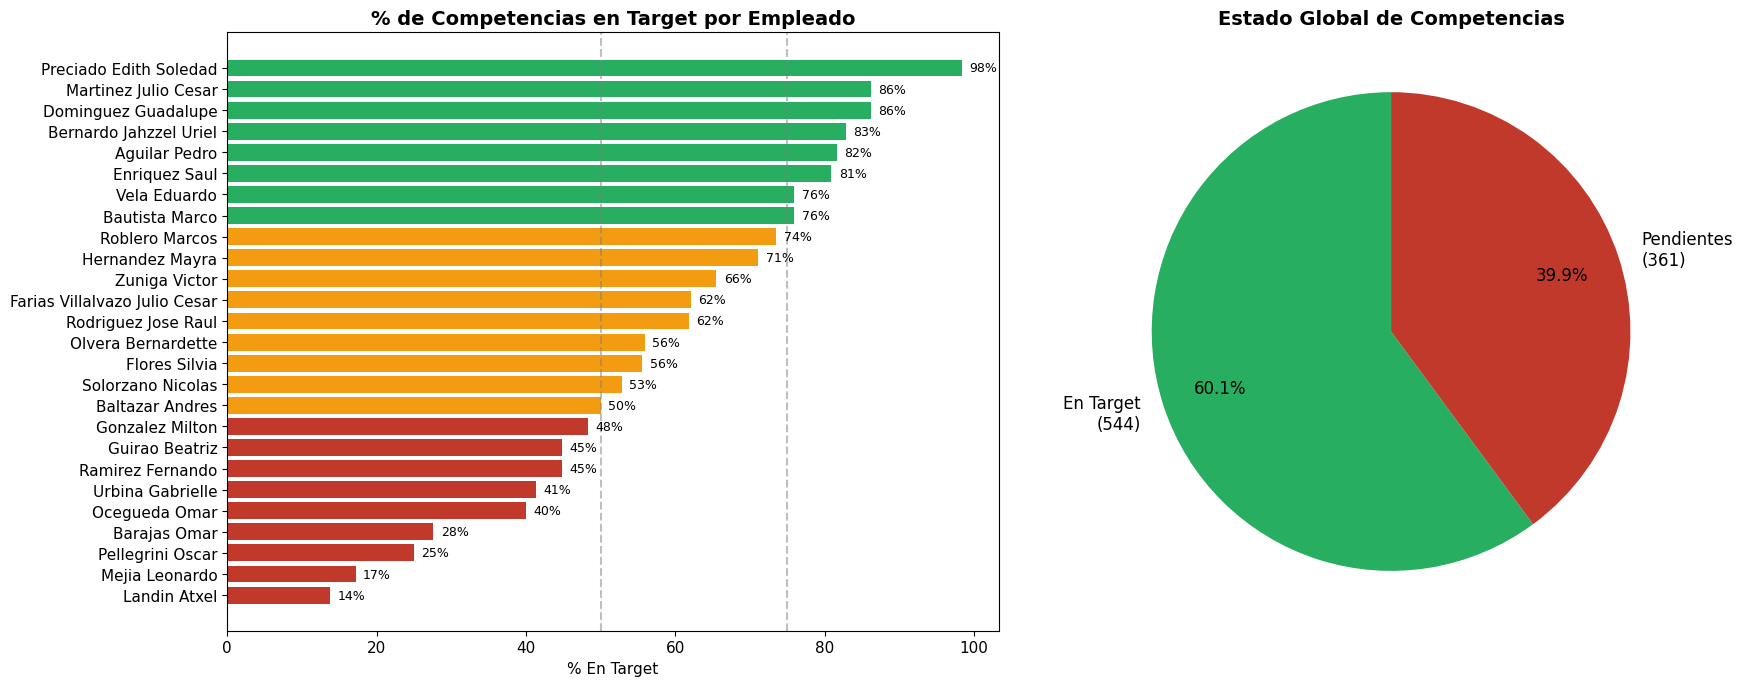

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1) % en target por empleado
emp_plot = emp.sort_values('%_En_Target', ascending=True)
colors = ['#c0392b' if v < 50 else '#f39c12' if v < 75 else '#27ae60' for v in emp_plot['%_En_Target']]
axes[0].barh(emp_plot['Employee'], emp_plot['%_En_Target'], color=colors)
axes[0].set_xlabel('% En Target')
axes[0].set_title('% de Competencias en Target por Empleado')
axes[0].axvline(x=50, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=75, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(emp_plot['%_En_Target']):
    axes[0].text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9)

# 2) Pie global
en_t = df['En_Target'].sum()
pend = len(df) - en_t
axes[1].pie([en_t, pend], labels=[f'En Target\n({en_t})', f'Pendientes\n({pend})'],
            colors=['#27ae60','#c0392b'], autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, pctdistance=0.75)
axes[1].set_title('Estado Global de Competencias')

plt.tight_layout()
plt.show()

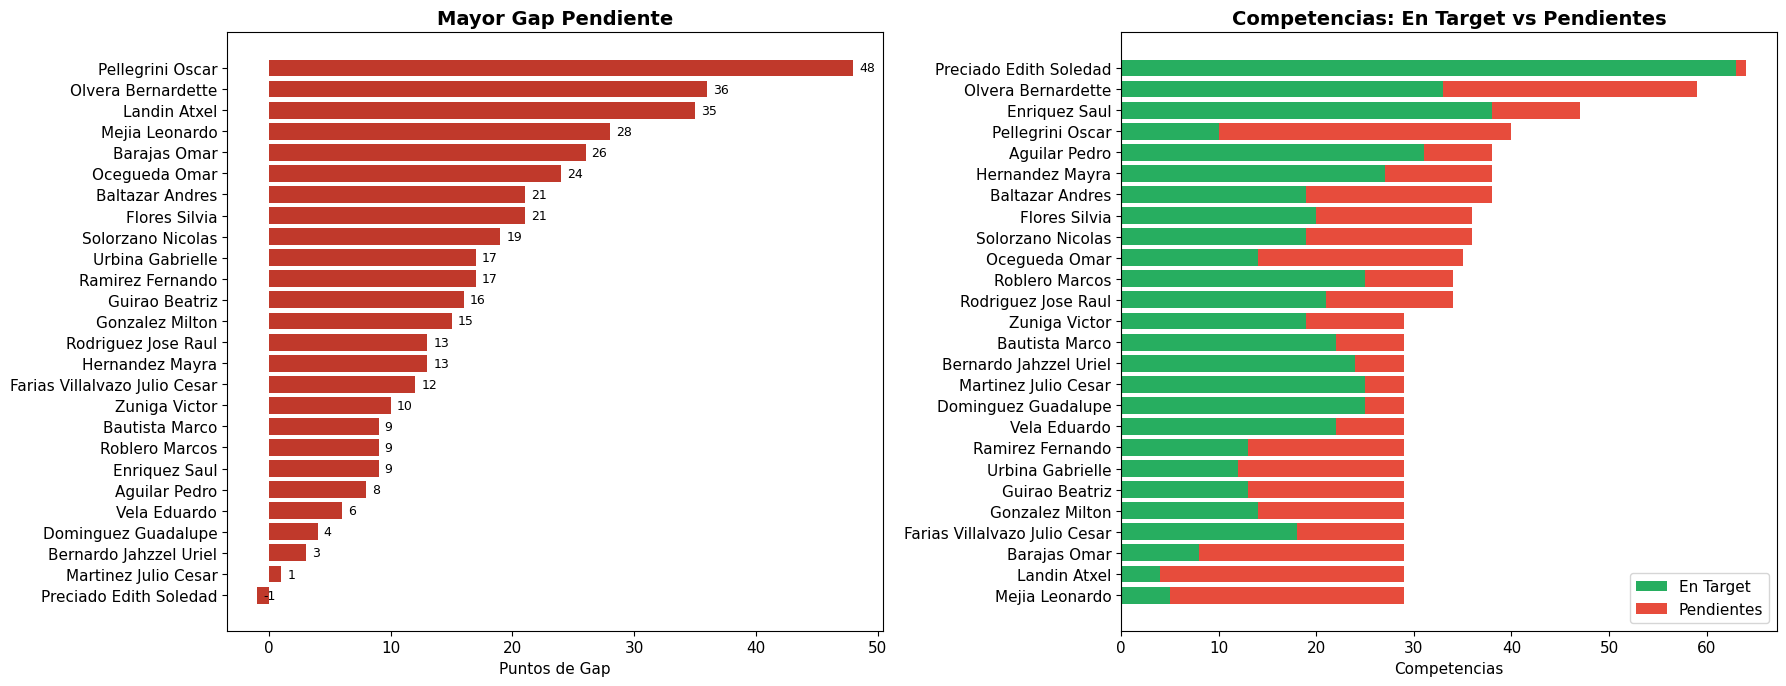

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 3) Gap actual por empleado (top 15)
emp_gap = emp.nlargest(30, 'Gap_Actual').sort_values('Gap_Actual', ascending=True)
axes[0].barh(emp_gap['Employee'], emp_gap['Gap_Actual'], color='#c0392b')
axes[0].set_xlabel('Puntos de Gap')
axes[0].set_title('Mayor Gap Pendiente')
for i, v in enumerate(emp_gap['Gap_Actual']):
    axes[0].text(v + 0.5, i, str(int(v)), va='center', fontsize=9)

# 4) Competencias en target vs pendientes (stacked)
emp_stack = emp.sort_values('Total', ascending=True)
axes[1].barh(emp_stack['Employee'], emp_stack['En_Target'], color='#27ae60', label='En Target')
axes[1].barh(emp_stack['Employee'], emp_stack['Pendientes'], left=emp_stack['En_Target'], color='#e74c3c', label='Pendientes')
axes[1].set_xlabel('Competencias')
axes[1].set_title('Competencias: En Target vs Pendientes')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 📅 Cambios Pendientes Programados

Tabla con los próximos cambios programados que **aún no se han completado** (donde el Current actual es menor al valor programado).

In [39]:
cambios = []
for _, r in df.iterrows():
    vals = [r[m] for m in MESES]
    for i in range(1, len(vals)):
        prev, cur = vals[i-1], vals[i]
        if pd.notna(prev) and pd.notna(cur) and cur != prev:
            if pd.notna(r['Current_DN']) and r['Current_DN'] < cur:
                cambios.append({
                    'Change_Type': f"{int(prev)}→{int(cur)}",
                    'Employee': r['Employee'],
                    'Month': MESES[i],
                    'Competency': r['Competency']
                })

cambios_df = pd.DataFrame(cambios, columns=['Change_Type','Employee','Month','Competency'])
mes_ord = {m: i for i, m in enumerate(MESES)}
cambios_df['_ord'] = cambios_df['Month'].map(mes_ord)
cambios_df = cambios_df.sort_values(['Employee','_ord','Competency']).drop(columns='_ord').reset_index(drop=True)

print(f"Total cambios pendientes: {len(cambios_df)}")
print(f"Empleados con cambios: {cambios_df['Employee'].nunique()}")
print(f"\nDistribución por mes:")
for m in MESES:
    n = (cambios_df['Month'] == m).sum()
    if n > 0:
        print(f"  {m}: {n} cambios")

display(cambios_df)

Total cambios pendientes: 231
Empleados con cambios: 25

Distribución por mes:
  Mar: 58 cambios
  Abr: 60 cambios
  May: 55 cambios
  Jun: 37 cambios
  Jul: 18 cambios
  Ago: 3 cambios


,Change_Type,Employee,Month,Competency
0,2→3,Aguilar Pedro,Mar,QRP
1,2→3,Aguilar Pedro,Abr,Safety Map
2,2→3,Aguilar Pedro,May,Safety Trigger
3,2→3,Baltazar Andres,Mar,5S
4,2→3,Baltazar Andres,Mar,CL DMS
...,...,...,...,...
226,2→3,Vela Eduardo,Jun,FPQ
227,1→2,Zuniga Victor,Mar,Q BOS
228,2→3,Zuniga Victor,Abr,IPS
229,2→3,Zuniga Victor,May,Q BOS


In [43]:
cambios_df.to_excel("archivo.xlsx", index=False)

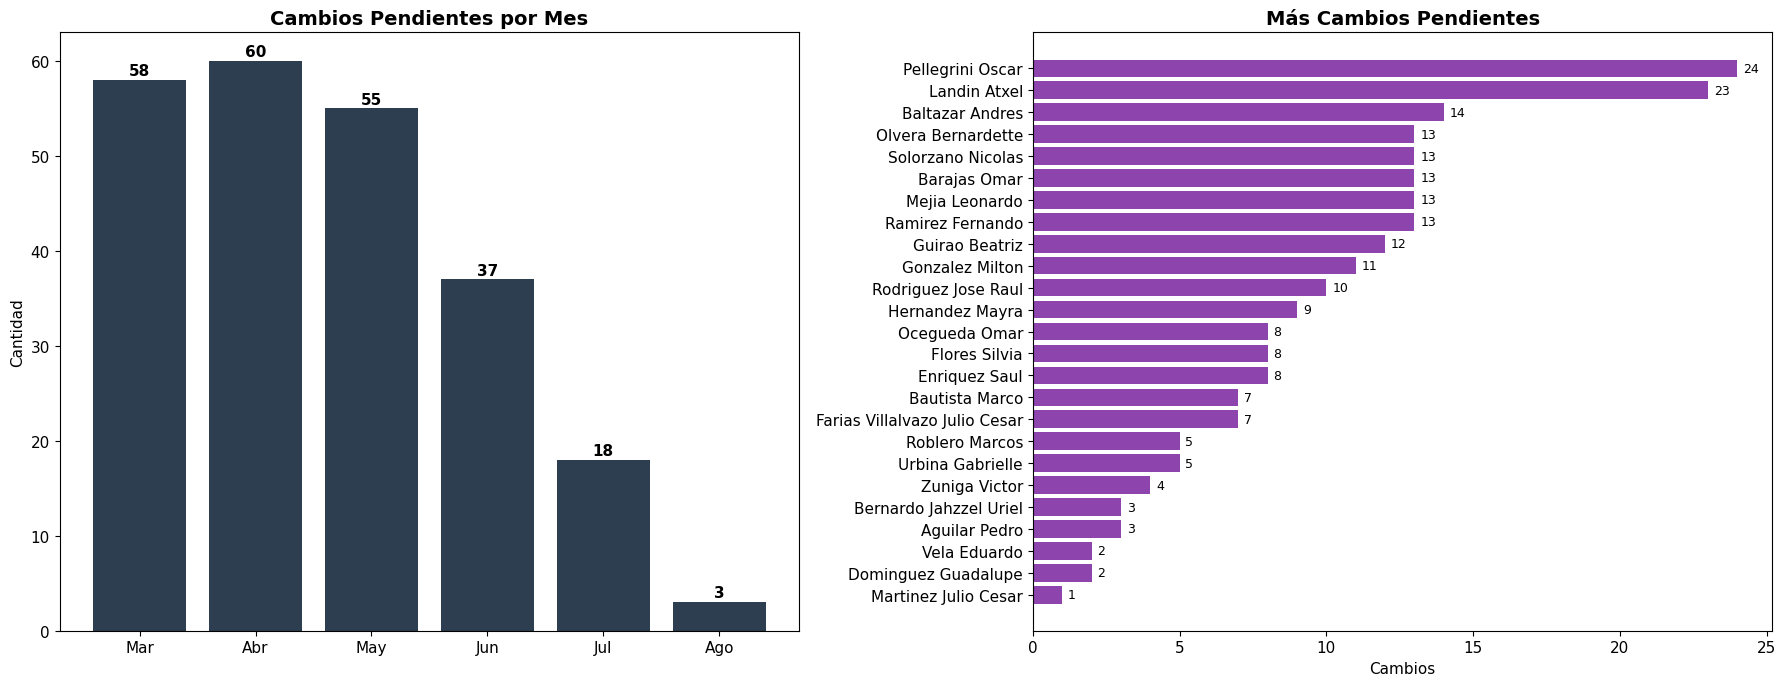

In [44]:
# Visualización: cambios pendientes por mes y empleado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Por mes
por_mes = cambios_df.groupby('Month').size().reindex([m for m in MESES if m in cambios_df['Month'].values])
axes[0].bar(por_mes.index, por_mes.values, color='#2c3e50')
axes[0].set_title('Cambios Pendientes por Mes')
axes[0].set_ylabel('Cantidad')
for i, v in enumerate(por_mes.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Por empleado (top 15)
por_emp = cambios_df.groupby('Employee').size().nlargest(30).sort_values(ascending=True)
axes[1].barh(por_emp.index, por_emp.values, color='#8e44ad')
axes[1].set_title('Más Cambios Pendientes')
axes[1].set_xlabel('Cambios')
for i, v in enumerate(por_emp.values):
    axes[1].text(v + 0.2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

## ⚠️ Registros sin coincidencia

In [41]:
if len(no_match) > 0:
    print(f"Los siguientes {len(no_match)} registros de QM-CAPS no tienen coincidencia en {DATA_FILE}:\n")
    display(no_match[['Employee','Competency','Role','Current_QM','Target_QM']].reset_index(drop=True))
else:
    print("✅ Todos los registros coinciden entre ambos archivos.")

Los siguientes 29 registros de QM-CAPS no tienen coincidencia en data_W12.xlsx:



,Employee,Competency,Role,Current_QM,Target_QM
0,Preciado Edith Soledad,Behavioral Observation,Line Coordinator - Phase 1,3,3
1,Preciado Edith Soledad,Coaching on the floor,Line Coordinator - Phase 1,1,2
2,Preciado Edith Soledad,ET Training Basic,Line Coordinator - Phase 1,2,2
3,Preciado Edith Soledad,High Risk Management,Line Coordinator - Phase 1,1,2
4,Preciado Edith Soledad,IOS OVERVIEW,Line Coordinator - Phase 1,2,2
5,Preciado Edith Soledad,Job Safety Analysis,Line Coordinator - Phase 1,2,2
6,Preciado Edith Soledad,Kaizen,Line Coordinator - Phase 1,3,3
7,Preciado Edith Soledad,QRP,Line Coordinator - Phase 1,3,3
8,Preciado Edith Soledad,Safety Map,Line Coordinator - Phase 1,3,3
9,Preciado Edith Soledad,Safety Trigger,Line Coordinator - Phase 1,3,3


---
## ✅ Fin del reporte

**Próximos pasos:**
- La próxima semana, actualiza `DATA_FILE` con el nuevo archivo y corre el notebook de nuevo
- Los avances semanales se mostrarán automáticamente comparando con el snapshot anterior
- Los snapshots se guardan en la carpeta `snapshots/`